In [1]:
import os
from pathlib import Path

import sys
import cv2
import pandas as pd
import supervision as sv
import numpy as np
import torch
import seaborn as sns
from torchcodec.decoders import VideoDecoder
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import pycocotools.mask as mask_util


from tqdm.auto import tqdm


In [3]:
VIDEO_DIR = Path("mnt/birds/rebecca2025/raw/")
OUTPUT_DIR = Path("/mnt/birds/rebecca2025/output")
output_subdirs = sorted(OUTPUT_DIR.glob("*/"))
output_subdirs

[PosixPath('/mnt/birds/rebecca2025/output/video_1'),
 PosixPath('/mnt/birds/rebecca2025/output/video_2'),
 PosixPath('/mnt/birds/rebecca2025/output/video_3')]

In [4]:
output_subdirs_d = {i: output_subdirs[i] for i in range(len(output_subdirs))}
output_subdirs_d

{0: PosixPath('/mnt/birds/rebecca2025/output/video_1'),
 1: PosixPath('/mnt/birds/rebecca2025/output/video_2'),
 2: PosixPath('/mnt/birds/rebecca2025/output/video_3')}

# Video 1

In [5]:
results_dir = output_subdirs_d.get(0)
results_dir

PosixPath('/mnt/birds/rebecca2025/output/video_1')

In [6]:
pq_files = sorted((results_dir.glob("*parquet")))
pq_files

[PosixPath('/mnt/birds/rebecca2025/output/video_1/test_video1_full_output_part1of5.parquet'),
 PosixPath('/mnt/birds/rebecca2025/output/video_1/test_video1_full_output_part2of5.parquet'),
 PosixPath('/mnt/birds/rebecca2025/output/video_1/test_video1_full_output_part3of5.parquet'),
 PosixPath('/mnt/birds/rebecca2025/output/video_1/test_video1_full_output_part4of5.parquet'),
 PosixPath('/mnt/birds/rebecca2025/output/video_1/test_video1_full_output_part5of5.parquet')]

In [7]:
df = pd.read_parquet(pq_files[0])
df

size  \
frame object_id               
31    0          [576, 704]   
      1          [576, 704]   
      2          [576, 704]   
32    0          [576, 704]   
      1          [576, 704]   
...                     ...   
4488  9          [576, 704]   
      10         [576, 704]   
4489  2          [576, 704]   
      9          [576, 704]   
      10         [576, 704]   

                                                            counts  \
frame object_id                                                      
31    0          Rhn88fa02M3M4K6L3M5K4K4E;L4M3L4M3L4M3N2O1O1O1O...   
      1          beh9`0\a06K5J6L3K5K5L4L4M3L4M2N3N1N2O1O2M2O1O1...   
      2          o_Q83la04L3N2N1N4L3L5K7K3M3M3M4L3M2O1N101N2O2M...   
32    0          n]P99ba08K4J7J5K5F9J7M2L3N3L4L4N3N1O1O1O1O100O...   
      1          jeh9221Za0d0I6L3L4L4L4L5K3N3M3M3M2N3M2O1N2O2M2...   
...                                                            ...   
4488  9          c[m01oa00L0W^O1ga05L4J6c^O@Wa0k0K0O2O0O101O002...   
      10         eek03la05L1c^ONj`04R_O5g`0MU_O6j`0a0O1O2NkNX_O...   
4489  2          d`W16ha03N2N2N101O0O2O00010O1O001O000010O00001...   
      9          c[m01oa00L0V^O1ia04K6I6N:H0O101N1000001O2N0O10...   
      10         eek03la05L1c^OOi`03S_O6f`0LW_O5h`0c0O102M17JN1...   

                                         bbox class     score  
frame object_id                                                
31    0          [509.0, 403.0, 561.0, 513.0]  bird  0.546875  
      1          [555.0, 434.0, 601.0, 537.0]  bird  0.535156  
      2          [457.0, 439.0, 536.0, 535.0]  bird  0.566406  
32    0          [512.0, 403.0, 561.0, 512.0]  bird  0.546875  
      1          [555.0, 435.0, 602.0, 537.0]  bird  0.535156  
...                                       ...   ...       ...  
4488  9            [50.0, 68.0, 147.0, 130.0]  bird  0.835938  
      10          [49.0, 116.0, 116.0, 186.0]  bird  0.832031  
4489  2           [68.0, 137.0, 213.0, 200.0]  bird  0.566406  
      9            [50.0, 68.0, 147.0, 130.0]  bird  0.835938  
      10          [49.0, 115.0, 116.0, 185.0]  bird  0.832031  

[13365 rows x 5 columns]

In [8]:
print(df.head())

                       size  \
frame object_id               
31    0          [576, 704]   
      1          [576, 704]   
      2          [576, 704]   
32    0          [576, 704]   
      1          [576, 704]   

                                                            counts  \
frame object_id                                                      
31    0          Rhn88fa02M3M4K6L3M5K4K4E;L4M3L4M3L4M3N2O1O1O1O...   
      1          beh9`0\a06K5J6L3K5K5L4L4M3L4M2N3N1N2O1O2M2O1O1...   
      2          o_Q83la04L3N2N1N4L3L5K7K3M3M3M4L3M2O1N101N2O2M...   
32    0          n]P99ba08K4J7J5K5F9J7M2L3N3L4L4N3N1O1O1O1O100O...   
      1          jeh9221Za0d0I6L3L4L4L4L5K3N3M3M3M2N3M2O1N2O2M2...   

                                         bbox class     score  
frame object_id                                                
31    0          [509.0, 403.0, 561.0, 513.0]  bird  0.546875  
      1          [555.0, 434.0, 601.0, 537.0]  bird  0.535156  
      2          [457.0, 439.0, 536

In [9]:
# idxs are list of tuples, where left is frame index and right is object index
df.index[0:5]

MultiIndex([(31, 0),
            (31, 1),
            (31, 2),
            (32, 0),
            (32, 1)],
           names=['frame', 'object_id'])

In [10]:
# Left is also refered to as index level 0
df.index.get_level_values(0)

Index([  31,   31,   31,   32,   32,   32,   33,   33,   33,   34,
       ...
       4486, 4487, 4487, 4487, 4488, 4488, 4488, 4489, 4489, 4489],
      dtype='int64', name='frame', length=13365)

In [11]:
# Right referred to as index level 1
df.index.get_level_values(1)

Index([ 0,  1,  2,  0,  1,  2,  0,  1,  2,  0,
       ...
       10,  2,  9, 10,  2,  9, 10,  2,  9, 10],
      dtype='int64', name='object_id', length=13365)

In [12]:
df.columns

Index(['size', 'counts', 'bbox', 'class', 'score'], dtype='str')

In [13]:
# Access frame 31, object_id 0
df.loc[(31, 0)]

size                                             [576, 704]
counts    Rhn88fa02M3M4K6L3M5K4K4E;L4M3L4M3L4M3N2O1O1O1O...
bbox                           [509.0, 403.0, 561.0, 513.0]
class                                                  bird
score                                              0.546875
Name: (31, 0), dtype: object

In [14]:
# Access 'counts' data from that same frame
df.loc[(31, 0), "counts"]

'Rhn88fa02M3M4K6L3M5K4K4E;L4M3L4M3L4M3N2O1O1O1O1O2N100O100O2O1N;F4L001O01O1O2N2M2N2O0O2N1N2O2I7I7K6J5K6J6I9I:D8Gf]_2'

In [15]:
df.index.unique("object_id")

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype='int64', name='object_id')

In [16]:
df.index.get_level_values("frame")

Index([  31,   31,   31,   32,   32,   32,   33,   33,   33,   34,
       ...
       4486, 4487, 4487, 4487, 4488, 4488, 4488, 4489, 4489, 4489],
      dtype='int64', name='frame', length=13365)

In [17]:
decoder = VideoDecoder("/mnt/birds/rebecca2025/raw/video_1_full.mp4", device="cpu")

In [18]:
meta = decoder.metadata
meta

VideoStreamMetadata:
  duration_seconds_from_header: 901.043478
  begin_stream_seconds_from_header: 0.0
  bit_rate: 1180169.0
  codec: h264
  stream_index: 0
  duration_seconds: 901.043478
  begin_stream_seconds: 0.0
  begin_stream_seconds_from_content: 0.0
  end_stream_seconds_from_content: 901.043478
  width: 704
  height: 576
  num_frames_from_header: 22451
  num_frames_from_content: 22451
  average_fps_from_header: 24.916667
  pixel_aspect_ratio: 0
  end_stream_seconds: 901.043478
  num_frames: 22451
  average_fps: 24.916667

In [19]:
total_frames = meta.num_frames
print(total_frames)
fps = round(meta.average_fps, 0)
print(fps)

22451
25.0


(0.0, 4489.0)

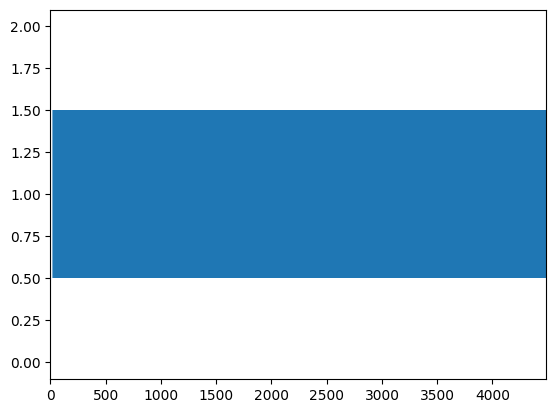

In [20]:
chunk_1_frame_idxs = np.arange(0, total_frames // 5)

plt.eventplot(df.index.get_level_values("frame"))
plt.xlim(0, chunk_1_frame_idxs.max())

We appear to have (basically) fully contiguous frame data for chunk 1 – astounding!

# Post-tracking identity consolidation

In [21]:
arr = mask_util.decode(
    [{"size": df.loc[(31, 0), "size"], "counts": df.loc[(31, 0), "counts"]}]
)
arr.shape

(576, 704, 1)

In [ ]:
def bbox_centroid(bbox):
    x1, y1, x2, y2 = bbox
    return np.array([(x1 + x2) / 2, (y1 + y2) / 2])


def mask_iou(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return inter / union if union > 0 else 0.0


def build_tracklets_from_df(df):
    """
    Returns:
      tracklets[object_id] = list of dicts with:
        frame, mask, centroid
    """
    tracklets = {}

    for (frame, oid), row in df.iterrows():
        mask = mask_util.decode({"counts": row["counts"], "size": row["size"]})
        centroid = bbox_centroid(row["bbox"])

        tracklets.setdefault(oid, []).append(
            {"frame": frame, "mask": mask, "centroid": centroid}
        )

    # sort by time
    for oid in tracklets:
        tracklets[oid] = sorted(tracklets[oid], key=lambda x: x["frame"])

    return tracklets


def compute_affinity_matrix(tracklets, frame_shape):
    """
    Returns:
      object_ids (list)
      affinity matrix (NxN)
    """
    ids = list(tracklets.keys())
    N = len(ids)
    H, W = frame_shape
    diag = np.sqrt(H * H + W * W)

    # frame → mask lookup
    frame_masks = {
        oid: {e["frame"]: e["mask"] for e in ents} for oid, ents in tracklets.items()
    }

    centroids = {
        oid: np.array([e["centroid"] for e in ents]) for oid, ents in tracklets.items()
    }

    A = np.eye(N)

    for i in range(N):
        for j in range(i + 1, N):
            oi, oj = ids[i], ids[j]
            common = set(frame_masks[oi]) & set(frame_masks[oj])

            if common:
                ious = [
                    mask_iou(frame_masks[oi][f], frame_masks[oj][f]) for f in common
                ]
                sim = float(np.mean(ious))
            else:
                c1, c2 = centroids[oi], centroids[oj]
                d = np.min(np.linalg.norm(c1[:, None] - c2[None, :], axis=2))
                sigma = 0.25 * diag
                sim = np.exp(-(d * d) / (2 * sigma * sigma))

            A[i, j] = A[j, i] = sim

    return ids, A


def cluster_original_ids(object_ids, affinity, K=3):
    """
    Returns mapping: original_object_id -> cluster_id (0..K-1)
    """
    dist = 1.0 - affinity
    condensed = squareform(dist, checks=False)
    Z = linkage(condensed, method="average")
    labels = fcluster(Z, t=K, criterion="maxclust")

    return {oid: int(lbl - 1) for oid, lbl in zip(object_ids, labels)}


def reassign_ids_per_frame(df, cluster_map):
    """
    Returns a Series aligned with df.index containing final stable_id (0..K-1)
    """
    stable_ids = pd.Series(index=df.index, dtype=int)

    # ---- precompute global cluster centroids ----
    cluster_centroids = {}
    for k in set(cluster_map.values()):
        oids = [oid for oid, cid in cluster_map.items() if cid == k]
        cluster_rows = df.loc[(slice(None), oids), :]

        if len(cluster_rows) == 0:
            cluster_centroids[k] = None
        else:
            cents = np.vstack([bbox_centroid(b) for b in cluster_rows["bbox"]])
            cluster_centroids[k] = cents.mean(axis=0)

    K = len(cluster_centroids)

    n_frames = df.index.get_level_values(0).nunique()

    for frame, frame_df in tqdm(
        df.groupby(level=0),
        total=n_frames,
        desc="Frames",
        dynamic_ncols=True,
    ):
        rows = frame_df.index.tolist()
        detections = frame_df.reset_index()

        Nd = len(detections)

        det_centroids = np.vstack([bbox_centroid(b) for b in detections["bbox"]])

        # IMPORTANT: rectangular cost matrix
        cost = np.zeros((Nd, K), dtype=float)

        for i in range(Nd):
            for k in range(K):
                mu = cluster_centroids[k]
                if mu is None:
                    cost[i, k] = 1e9
                else:
                    cost[i, k] = np.linalg.norm(det_centroids[i] - mu)

        row_ind, col_ind = linear_sum_assignment(cost)

        for i, k in zip(row_ind, col_ind):
            stable_ids.loc[rows[i]] = k

        # Optional: mark unassigned identities explicitly
        # (only relevant if Nd < K)
        # for k in set(range(K)) - set(col_ind):
        #     pass

    return stable_ids


def enforce_ids(df, K=3):
    tracklets = build_tracklets_from_df(df)

    H, W = df.iloc[0]["size"]
    object_ids, affinity = compute_affinity_matrix(tracklets, (H, W))
    cluster_map = cluster_original_ids(object_ids, affinity, K=K)

    stable_ids = reassign_ids_per_frame(df, cluster_map)
    df.assign(stable_id=stable_ids)

    return df.assign(stable_id=stable_ids), cluster_map, affinity


In [37]:
df_stable_ids, clustermap, affinity = enforce_ids(df)

Frames: 100%|██████████| 4459/4459 [00:03<00:00, 1469.05it/s]


In [24]:
df_stable_id_replaced = (
    df_stable_ids.reset_index(level=1, drop=True)
    .set_index("stable_id", append=True)
    .sort_index()
    .rename_axis(index={"stable_id": "object_id"})
)


In [25]:
df_stable_id_replaced

size  \
frame object_id               
31    0.0        [576, 704]   
      1.0        [576, 704]   
      2.0        [576, 704]   
32    0.0        [576, 704]   
      1.0        [576, 704]   
...                     ...   
4488  1.0        [576, 704]   
      2.0        [576, 704]   
4489  0.0        [576, 704]   
      1.0        [576, 704]   
      2.0        [576, 704]   

                                                            counts  \
frame object_id                                                      
31    0.0        beh9`0\a06K5J6L3K5K5L4L4M3L4M2N3N1N2O1O2M2O1O1...   
      1.0        o_Q83la04L3N2N1N4L3L5K7K3M3M3M4L3M2O1N101N2O2M...   
      2.0        Rhn88fa02M3M4K6L3M5K4K4E;L4M3L4M3L4M3N2O1O1O1O...   
32    0.0        jeh9221Za0d0I6L3L4L4L4L5K3N3M3M3M2N3M2O1N2O2M2...   
      1.0        nQR87ha03M3N2M3N2L5L4L5L3M4L4L2N3N1N101N3N1N2O...   
...                                                            ...   
4488  1.0        d`W17ga03N1O2N101O1O001O001O001O0010O0000001O0...   
      2.0        eek03la05L1c^ONj`04R_O5g`0MU_O6j`0a0O1O2NkNX_O...   
4489  0.0        c[m01oa00L0V^O1ia04K6I6N:H0O101N1000001O2N0O10...   
      1.0        d`W16ha03N2N2N101O0O2O00010O1O001O000010O00001...   
      2.0        eek03la05L1c^OOi`03S_O6f`0LW_O5h`0c0O102M17JN1...   

                                         bbox class     score  
frame object_id                                                
31    0.0        [555.0, 434.0, 601.0, 537.0]  bird  0.535156  
      1.0        [457.0, 439.0, 536.0, 535.0]  bird  0.566406  
      2.0        [509.0, 403.0, 561.0, 513.0]  bird  0.546875  
32    0.0        [555.0, 435.0, 602.0, 537.0]  bird  0.535156  
      1.0        [458.0, 439.0, 536.0, 528.0]  bird  0.566406  
...                                       ...   ...       ...  
4488  1.0         [69.0, 137.0, 213.0, 200.0]  bird  0.566406  
      2.0         [49.0, 116.0, 116.0, 186.0]  bird  0.832031  
4489  0.0          [50.0, 68.0, 147.0, 130.0]  bird  0.835938  
      1.0         [68.0, 137.0, 213.0, 200.0]  bird  0.566406  
      2.0         [49.0, 115.0, 116.0, 185.0]  bird  0.832031  

[13365 rows x 5 columns]

In [ ]:
def annotate_frame(frame_rgb: np.ndarray, frame_df: pd.DataFrame):
    H, W = frame_rgb.shape[:2]

    xyxy_list = []
    mask_list = []
    class_ids = []
    tracker_ids = []
    labels = []

    for object_id, row in frame_df.iterrows():
        # ---------- 1) Decode mask with pycoco, resize to (H, W) ----------
        mask = None
        rle_counts = row.get("counts")
        rle_size = row.get("size")

        if (
            isinstance(rle_counts, str)
            and rle_counts
            and isinstance(rle_size, (list, tuple))
        ):
            try:
                rle = {"counts": rle_counts, "size": rle_size}
                m = mask_util.decode(rle)  # (h,w) or (h,w,1)
                if m.ndim == 3:
                    m = m[..., 0]
                if m.shape != (H, W):  # supervision requires (H,W)
                    m = cv2.resize(
                        m.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST
                    )
                mask = m > 0
            except Exception:
                mask = None

        # ---------- 2) Bbox: require a valid 4-tuple, convert to pixel xyxy ----------
        bbox = row.get("bbox")
        if not (isinstance(bbox, (list, tuple, np.ndarray)) and len(bbox) == 4):
            # No valid bbox → skip this detection entirely (keep lists aligned)
            continue

        bbox = np.array(bbox, dtype=float)
        # normalized → pixel
        if np.nanmax(bbox) <= 2.0:
            bbox[[0, 2]] *= W
            bbox[[1, 3]] *= H

        # clip and validate
        bbox[0::2] = np.clip(bbox[0::2], 0, W - 1)
        bbox[1::2] = np.clip(bbox[1::2], 0, H - 1)
        if not (bbox[2] > bbox[0] and bbox[3] > bbox[1]):
            # degenerate bbox -> skip
            continue

        # ---------- 3) Append in lockstep ----------
        xyxy_list.append(bbox)

        if mask is None:
            mask = np.zeros((H, W), dtype=bool)
        mask_list.append(mask)

        # IDs and labels:
        # - class_id must be NON-NEGATIVE (palette index)
        # - tracker_id used for stable colors with ColorLookup.TRACK
        if pd.isna(object_id):
            class_ids.append(0)  # reserve 0 for 'undefined'
            tracker_ids.append(0)  # group undefined under a neutral track id
            labels.append("undefined")
        else:
            oid = int(object_id)
            class_ids.append(oid + 1)  # shift by +1 to keep >=1
            tracker_ids.append(oid)  # true object_id for color-by-track
            labels.append(f"ID {oid}")

    # Nothing to draw
    if not xyxy_list:
        return frame_rgb

    # Build detections with aligned arrays
    xyxy = np.asarray(xyxy_list, dtype=np.float32)
    masks = np.stack(mask_list, axis=0).astype(bool)
    class_ids = np.asarray(class_ids, dtype=int)
    tracker_ids = np.asarray(tracker_ids, dtype=int)

    detections = sv.Detections(
        xyxy=xyxy,
        mask=masks,
        class_id=class_ids,
        tracker_id=tracker_ids,
    )

    # Annotators
    mask_annotator = sv.MaskAnnotator(opacity=0.4)
    box_annotator = sv.BoxAnnotator(thickness=2)
    label_annotator = sv.LabelAnnotator(text_scale=0.6, text_thickness=1)

    # Use TRACK lookup to color by tracker_id (your object_id)
    out = mask_annotator.annotate(
        scene=frame_rgb.copy(),
        detections=detections,
        custom_color_lookup=sv.ColorLookup.TRACK,
    )
    out = box_annotator.annotate(
        scene=out,
        detections=detections,
        custom_color_lookup=sv.ColorLookup.TRACK,
    )
    out = label_annotator.annotate(out, detections, labels=labels)

    return out


In [ ]:
def write_annotated_video(decoder, df, output_path):
    fps = round(decoder.metadata.fps, 0)
    first_frame = decoder[0].numpy().transpose(1, 2, 0)
    h, w, _ = first_frame.shape

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w, h),
    )

    frame_idxs = sorted(df.index.get_level_values(0).unique())

    for frame_idx in tqdm(frame_idxs, desc="Writing video"):
        # CHW → HWC
        frame_rgb = decoder[frame_idx].numpy().transpose(1, 2, 0)

        frame_df = df.loc[frame_idx]
        annotated = annotate_frame(frame_rgb, frame_df)

        writer.write(cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))

    writer.release()

In [ ]:
write_annotated_video(
    decoder=decoder,
    df=df_stable_id_replaced,
    output_path="/mnt/birds/rebecca2025/annotated_video.mp4",
)

Writing video: 100%|██████████| 4459/4459 [00:18<00:00, 235.04it/s]


# Plot ethogram data onto video (requires proper ID matching)

In [58]:
etho_df = pd.read_parquet("../data/C1G1_ethogram_converted.parquet")
etho_df.head()

,object_id,timestamp,timestamp_str,action
0,4,0 days 00:00:05,0:00:05,
1,4,0 days 00:00:10,0:00:10,Frolicking
2,4,0 days 00:00:15,0:00:15,Frolicking
3,4,0 days 00:00:20,0:00:20,
4,4,0 days 00:00:25,0:00:25,Frolicking
